# SYS-304 — Milestone 1: Problem Scoping & Prototype
## Domain: House Prices — Advanced Regression Techniques (Tabular Regression)

**Goal:** Build a "naive" baseline prototype that maps house features to `SalePrice`.
This notebook covers: data loading, EDA, a simple baseline model, evaluation, and saving the trained model.

> Dataset: Kaggle *House Prices - Advanced Regression Techniques*. For this prototype run, a
> synthetic dataset with the same schema/column names is used as a stand-in (see `data/generate_synthetic_data.py`).
> Drop the real `train.csv` from Kaggle into `data/` and re-run — no code changes needed.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Load Data

In [2]:
df = pd.read_csv("data/train.csv")
print(df.shape)
df.head()

(1460, 21)


,Id,MSSubClass,LotFrontage,LotArea,Neighborhood,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,...,GrLivArea,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,GarageYrBlt,CentralAir,SalePrice
0,1,45,NaN,9631.0,ClearCr,1.5Fin,1,7,1987,2006,...,1693.0,0,0,3,7,1,3,1987.0,Y,156161.0
1,2,20,102.361017,9662.0,NWAmes,SLvl,8,9,1934,1938,...,2267.0,3,0,1,5,0,1,1937.0,Y,243730.0
2,3,40,67.473088,12062.0,Edwards,1.5Fin,7,3,1905,1907,...,2156.0,1,0,1,4,0,1,1908.0,Y,193914.0
3,4,60,96.619629,16105.0,SWISU,1.5Fin,5,6,1905,1905,...,2270.0,1,0,5,9,0,3,1907.0,Y,233660.0
4,5,75,38.238507,11225.0,Blmngtn,1.5Fin,5,7,1994,2010,...,1699.0,1,1,3,5,0,2,1998.0,N,211823.0


## 3. Exploratory Data Analysis (EDA)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            1460 non-null   int64  
 1   MSSubClass    1460 non-null   int64  
 2   LotFrontage   1176 non-null   float64
 3   LotArea       1460 non-null   float64
 4   Neighborhood  1460 non-null   str    
 5   HouseStyle    1460 non-null   str    
 6   OverallQual   1460 non-null   int64  
 7   OverallCond   1460 non-null   int64  
 8   YearBuilt     1460 non-null   int64  
 9   YearRemodAdd  1460 non-null   int64  
 10  TotalBsmtSF   1460 non-null   float64
 11  GrLivArea     1460 non-null   float64
 12  FullBath      1460 non-null   int64  
 13  HalfBath      1460 non-null   int64  
 14  BedroomAbvGr  1460 non-null   int64  
 15  TotRmsAbvGrd  1460 non-null   int64  
 16  Fireplaces    1460 non-null   int64  
 17  GarageCars    1460 non-null   int64  
 18  GarageYrBlt   1070 non-null   float64
 

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.750000,730.500000,1095.250000,1460.000000
MSSubClass,1460.0,59.109589,22.980345,20.0,40.000000,60.000000,80.000000,90.000000
LotFrontage,1176.0,70.771563,19.860776,20.0,56.490152,69.827093,84.932603,123.762245
LotArea,1460.0,10352.744521,4009.826649,1500.0,7688.750000,10439.500000,13039.250000,22738.000000
OverallQual,1460.0,5.578082,2.875781,1.0,3.000000,6.000000,8.000000,10.000000
OverallCond,1460.0,5.003425,2.587864,1.0,3.000000,5.000000,7.000000,9.000000
YearBuilt,1460.0,1954.279452,32.328272,1900.0,1926.000000,1952.000000,1983.000000,2010.000000
YearRemodAdd,1460.0,1966.970548,31.445109,1900.0,1940.000000,1968.000000,1997.000000,2010.000000
TotalBsmtSF,1460.0,1201.177397,473.875685,191.0,836.000000,1138.000000,1494.250000,3000.000000
GrLivArea,1460.0,1734.156164,505.585366,400.0,1378.000000,1728.000000,2059.000000,3627.000000


### 3.1 Missing Values

GarageYrBlt    390
LotFrontage    284
dtype: int64


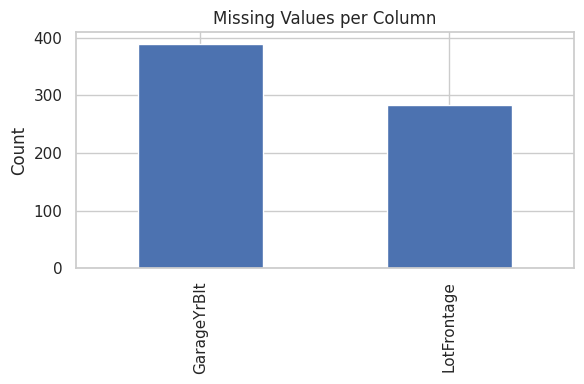

In [5]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

plt.figure(figsize=(6,4))
missing.plot(kind="bar")
plt.title("Missing Values per Column")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 3.2 Target Distribution — `SalePrice`

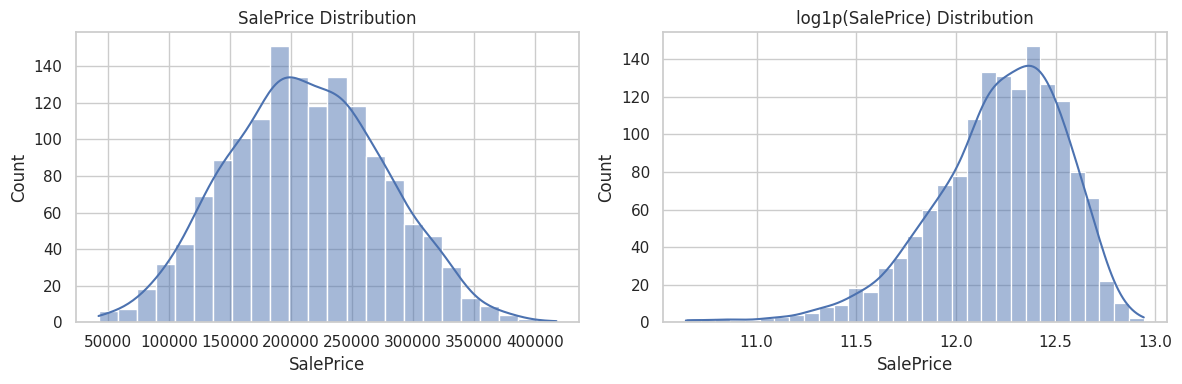

count      1460.000000
mean     212316.156849
std       63441.958726
min       41974.000000
25%      167128.500000
50%      211181.000000
75%      256208.000000
max      417699.000000
Name: SalePrice, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title("SalePrice Distribution")
sns.histplot(np.log1p(df["SalePrice"]), kde=True, ax=axes[1])
axes[1].set_title("log1p(SalePrice) Distribution")
plt.tight_layout()
plt.show()

print(df["SalePrice"].describe())

### 3.3 Feature Correlations

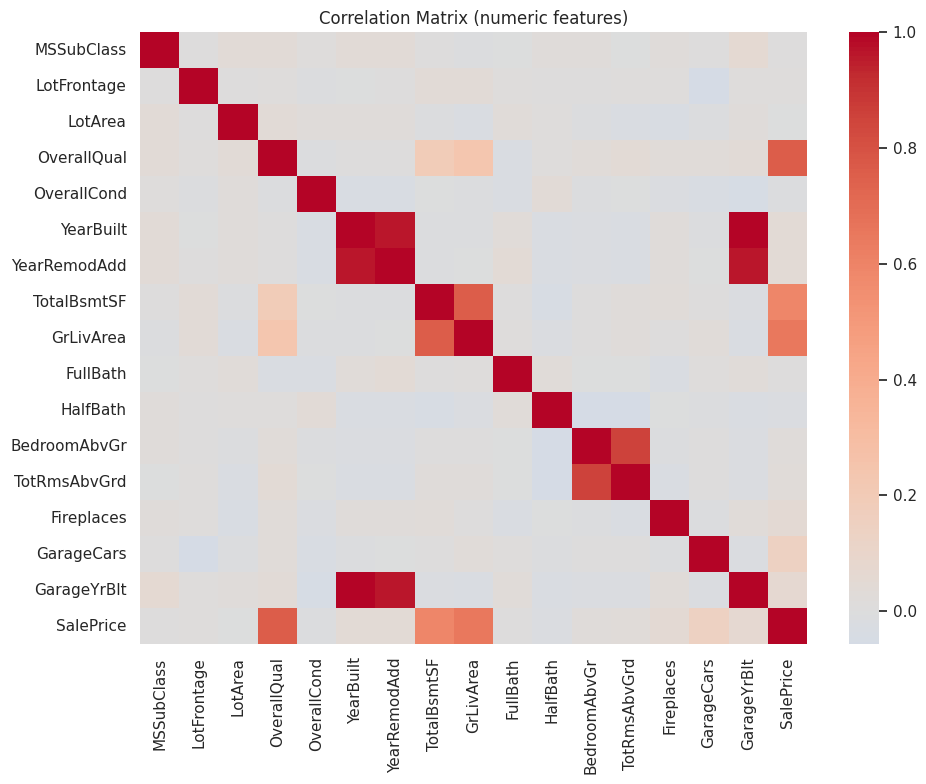

SalePrice       1.000000
OverallQual     0.763518
GrLivArea       0.649456
TotalBsmtSF     0.587750
GarageCars      0.143843
GarageYrBlt     0.068097
Fireplaces      0.052932
YearRemodAdd    0.047586
YearBuilt       0.046193
TotRmsAbvGrd    0.033091
BedroomAbvGr    0.018253
LotFrontage     0.016968
FullBath        0.002687
MSSubClass      0.001786
LotArea        -0.004390
OverallCond    -0.013588
HalfBath       -0.018146
Name: SalePrice, dtype: float64

In [7]:
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=["Id"])
corr = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Matrix (numeric features)")
plt.tight_layout()
plt.show()

corr["SalePrice"].sort_values(ascending=False)

### 3.4 Key Relationships

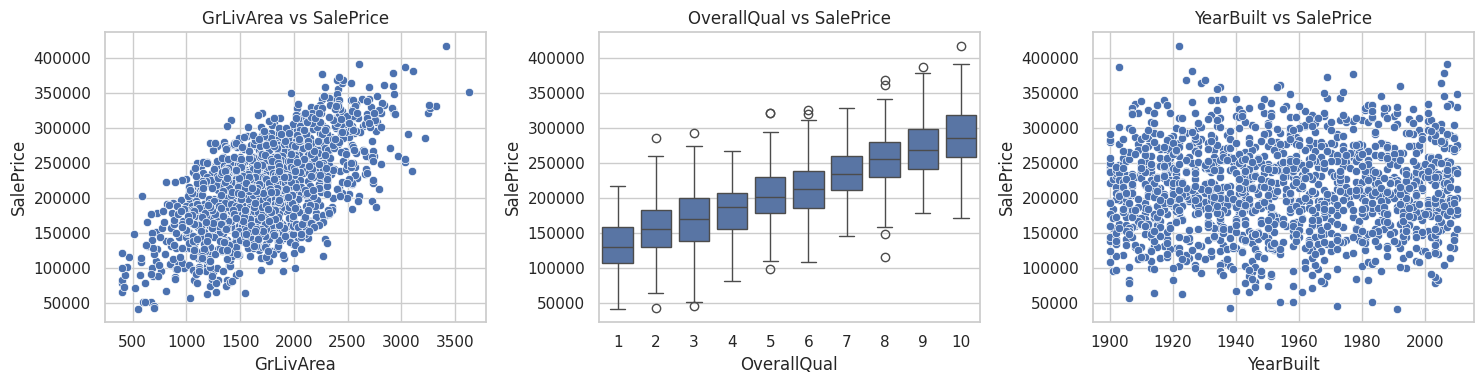

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.scatterplot(data=df, x="GrLivArea", y="SalePrice", ax=axes[0])
axes[0].set_title("GrLivArea vs SalePrice")
sns.boxplot(data=df, x="OverallQual", y="SalePrice", ax=axes[1])
axes[1].set_title("OverallQual vs SalePrice")
sns.scatterplot(data=df, x="YearBuilt", y="SalePrice", ax=axes[2])
axes[2].set_title("YearBuilt vs SalePrice")
plt.tight_layout()
plt.show()

## 4. Data Pipeline
Simple, reproducible preprocessing:
- Numeric features → median imputation
- Categorical features → most-frequent imputation + one-hot encoding

This is intentionally minimal — the goal at this stage is a working baseline, not
exhaustive feature engineering.

In [9]:
target = "SalePrice"
features = [c for c in df.columns if c not in ["Id", target]]

X = df[features]
y = df[target]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Numeric features: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'TotalBsmtSF', 'GrLivArea', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageYrBlt']
Categorical features: ['Neighborhood', 'HouseStyle', 'CentralAir']
Train: (1168, 19), Test: (292, 19)


In [10]:
numeric_transformer = SimpleImputer(strategy="median")

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

## 5. Train Baseline Model
A naive baseline: `XGBRegressor` with default-ish hyperparameters, no tuning.
This establishes a floor to compare later, more sophisticated systems against.

In [11]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

model.fit(X_train, y_train)
print("Training complete.")

Training complete.


## 6. Evaluation

In [12]:
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
rmsle = np.sqrt(mean_squared_error(np.log1p(y_test), np.log1p(np.clip(preds, 0, None))))

print(f"MAE   : ${mae:,.2f}")
print(f"RMSE  : ${rmse:,.2f}")
print(f"R^2   : {r2:.4f}")
print(f"RMSLE : {rmsle:.4f}  (this is the actual Kaggle competition metric)")

MAE   : $17,299.64
RMSE  : $21,610.45
R^2   : 0.8835
RMSLE : 0.1328  (this is the actual Kaggle competition metric)


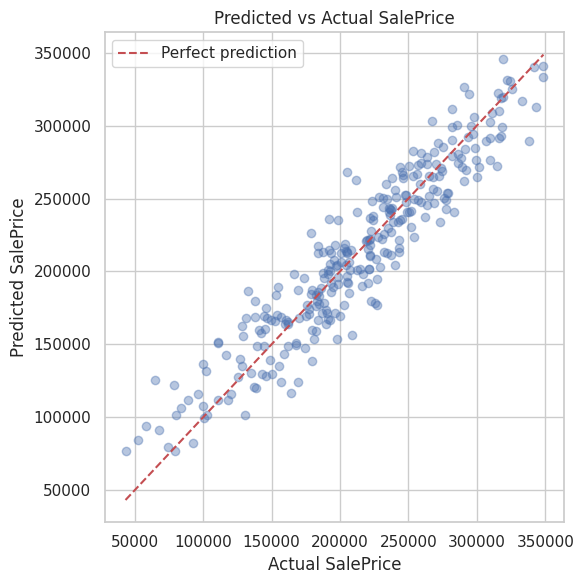

In [13]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, preds, alpha=0.4)
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
plt.plot(lims, lims, 'r--', label="Perfect prediction")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Predicted vs Actual SalePrice")
plt.legend()
plt.tight_layout()
plt.show()

### Feature Importance

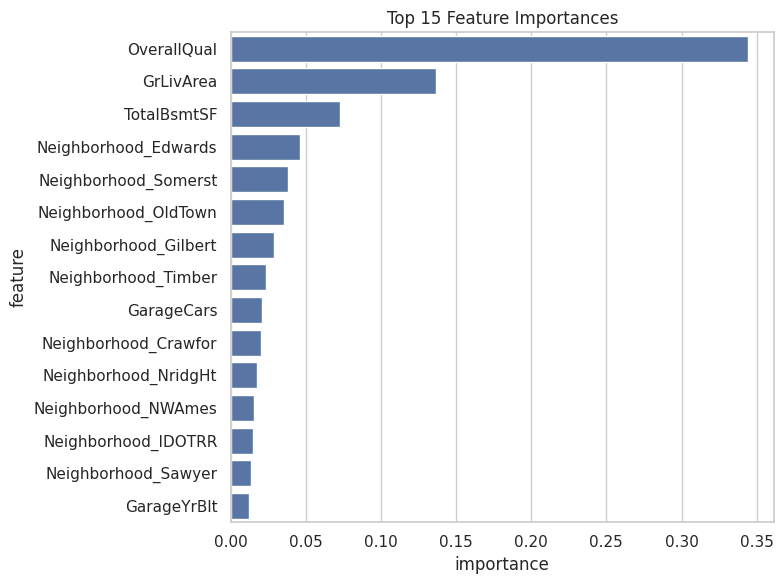

In [14]:
ohe = model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_names)

importances = model.named_steps["regressor"].feature_importances_
imp_df = pd.DataFrame({"feature": all_feature_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(data=imp_df, x="importance", y="feature")
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()

## 7. Save Model Weights
Saving the full pipeline (preprocessing + model) so the notebook can be re-run for
inference/demo without retraining, as allowed for the video recording deliverable.

In [15]:
import os
os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/baseline_xgb_pipeline.pkl")
print("Model saved to models/baseline_xgb_pipeline.pkl")

Model saved to models/baseline_xgb_pipeline.pkl


## 8. Reload Model & Demo Predictions
This cell demonstrates loading the saved weights and running inference —
this is the part that can be shown in the screen recording without re-running training.

In [16]:
loaded_model = joblib.load("models/baseline_xgb_pipeline.pkl")

sample = X_test.head(5)
sample_preds = loaded_model.predict(sample)

results = pd.DataFrame({
    "Actual SalePrice": y_test.head(5).values,
    "Predicted SalePrice": sample_preds.round(0),
})
results["Abs Error"] = (results["Actual SalePrice"] - results["Predicted SalePrice"]).abs()
results

,Actual SalePrice,Predicted SalePrice,Abs Error
0,277792.0,249231.0,28561.0
1,120126.0,115787.0,4339.0
2,182445.0,176641.0,5804.0
3,101814.0,131981.0,30167.0
4,275673.0,250158.0,25515.0


## 9. Next Steps (Beyond This Prototype)
- Hyperparameter tuning (grid/random/Bayesian search) on the XGBoost model
- Feature engineering: total square footage, age at sale, quality×area interactions
- Try alternative baselines (LightGBM, a small NN) and compare
- Handle outliers / skew in `SalePrice` more carefully (e.g. model on `log1p(SalePrice)`)
- Cross-validation instead of a single train/test split for more robust metrics